# 中华麋鹿园携程评价数据分析

> 数据来源：携程（Ctrip）中华麋鹿园景区用户评价
> 分析框架：评分口碑 · 时间趋势 · 用户画像 · 文本情感

本 Notebook 与项目中的 Python 脚本（`src/config.py`、`src/data_utils.py` 及各生成脚本）共用同一套配置与预处理逻辑，
把完整的分析流程以「可逐格运行、边看边学」的方式呈现。每格代码独立可读，图表直接内联显示。

运行建议：在 Jupyter Lab / Notebook 中「Restart & Run All」即可一次性复现全部结论。

## 0. 运行环境准备

把项目 `src/` 目录加入 Python 路径，以便复用 `config`（统一配置）与 `data_utils`（数据加载 / 分词）模块；
并设置 matplotlib 中文字体，避免图表中文显示为方块。

In [29]:
import sys
import os
from pathlib import Path

# 把项目 src 目录加入 Python 路径，以便复用 config / data_utils 模块。
# 兼容两种启动方式：从项目根目录启动、或从 notebooks/ 目录启动（向上查找含 config.py 的 src）。
def find_src():
    here = Path.cwd()
    for base in (here, here.parent, here.parent.parent):
        cand = base / "src"
        if (cand / "config.py").exists():
            return cand
    return None

SRC = find_src()
if SRC is None:
    raise RuntimeError("找不到 src/config.py，请确认从项目根目录或 notebooks/ 启动 Jupyter")
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("已加载 src 目录:", SRC)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

import jieba
import data_utils
import config

# 在 Notebook 中内联显示图表
%matplotlib inline
plt.style.use("default")  # 重置为 matplotlib 默认样式，避免继承到暗色主题
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.unicode_minus"] = False  # 正常显示负号

def setup_chinese_font():
    candidates = ["Microsoft YaHei", "SimHei", "SimSun", "STHeiti", "WenQuanYi Micro Hei"]
    for name in candidates:
        try:
            fp = font_manager.FontProperties(family=name)
            matplotlib.rcParams["font.family"] = fp.get_name()
            print("使用中文字体:", name)
            return fp
        except Exception:
            continue
    print("未找到中文字体，将使用默认字体")
    return None

font = setup_chinese_font()
print("项目根目录:", config.PROJECT_ROOT)
print("数据目录  :", config.DATA_DIR)

已加载 src 目录: D:\Users\39819\Desktop\ctrip-milu-park-analysis-main\src
使用中文字体: Microsoft YaHei
项目根目录: D:\Users\39819\Desktop\ctrip-milu-park-analysis-main
数据目录  : D:\Users\39819\Desktop\ctrip-milu-park-analysis-main\data


## 1. 数据加载

使用 `data_utils.load_reviews()` 作为统一数据入口：读取 CSV 后自动补全时间维度（年份 / 月份 / 季节）
与衍生特征（评论字数、评分等级），返回全量 `df` 与时间解析成功的 `df_valid`。

In [30]:
# 统一数据入口：读取并预处理
df, df_valid = data_utils.load_reviews()

print(f"全量评价数 : {len(df)} 条")
print(f"有效时间记录: {len(df_valid)} 条")
print(f"时间范围   : {df_valid['发布时间_dt'].min().date()} ~ {df_valid['发布时间_dt'].max().date()}")
print(f"平均总评分 : {df['总评分'].mean():.2f} 分")
print(f"平均评论字数: {df_valid['评论字数'].mean():.0f} 字")

df.head()

全量评价数 : 3050 条
有效时间记录: 3050 条
时间范围   : 2016-05-05 ~ 2026-07-12
平均总评分 : 4.50 分
平均评论字数: 38 字


,评论ID,用户昵称,用户等级,总评分,景色评分,趣味评分,性价比评分,评论内容,发布时间,发布标签,...,评论链接,语言,发布时间_dt,年份,月份,年月,季度,季节,评论字数,评分等级
0,749060761,匿名用户,NaN,5.0,5.0,5.0,5.0,好好好好好,2026-07-12 14:03:00,2026-07-12 发布点评,...,https://m.ctrip.com/webapp/you/comment/detail/...,zh-cn,2026-07-12 14:03:00,2026,7,2026-07,3,秋季(7-9月),5,好评(4-5星)
1,748477472,YoYo_9C6C4F7X,铂金贵宾,5.0,5.0,5.0,5.0,很好，玩得快乐,2026-07-11 20:05:25,2026-07-11 发布点评,...,https://m.ctrip.com/webapp/you/comment/detail/...,zh-cn,2026-07-11 20:05:25,2026,7,2026-07,3,秋季(7-9月),7,好评(4-5星)
2,748378590,Timi兀,钻石贵宾,5.0,5.0,5.0,5.0,可可爱爱‘的麋鹿🫎’,2026-07-11 16:01:28,2026-07-11 发布点评,...,https://m.ctrip.com/webapp/you/comment/detail/...,zh-cn,2026-07-11 16:01:28,2026,7,2026-07,3,秋季(7-9月),10,好评(4-5星)
3,748276985,七校长呢,铂金贵宾,5.0,5.0,5.0,5.0,值得一去的地方,2026-07-11 12:31:40,2026-07-11 发布点评,...,https://m.ctrip.com/webapp/you/comment/detail/...,zh-cn,2026-07-11 12:31:40,2026,7,2026-07,3,秋季(7-9月),7,好评(4-5星)
4,748118050,YoYo_3X4Z9N6D,黄金贵宾,5.0,5.0,5.0,5.0,景区宠物友好 观光车小狗也可以乘坐,2026-07-11 08:04:48,2026-07-11 发布点评,...,https://m.ctrip.com/webapp/you/comment/detail/...,zh-cn,2026-07-11 08:04:48,2026,7,2026-07,3,秋季(7-9月),17,好评(4-5星)


## 2. 整体口碑：评分分布

饼图展示 1–5 星评价的数量与占比。小扇区容易互相遮挡，因此这里把标签放到右侧图例、
并对各扇区做轻微分离，保证清晰可读。

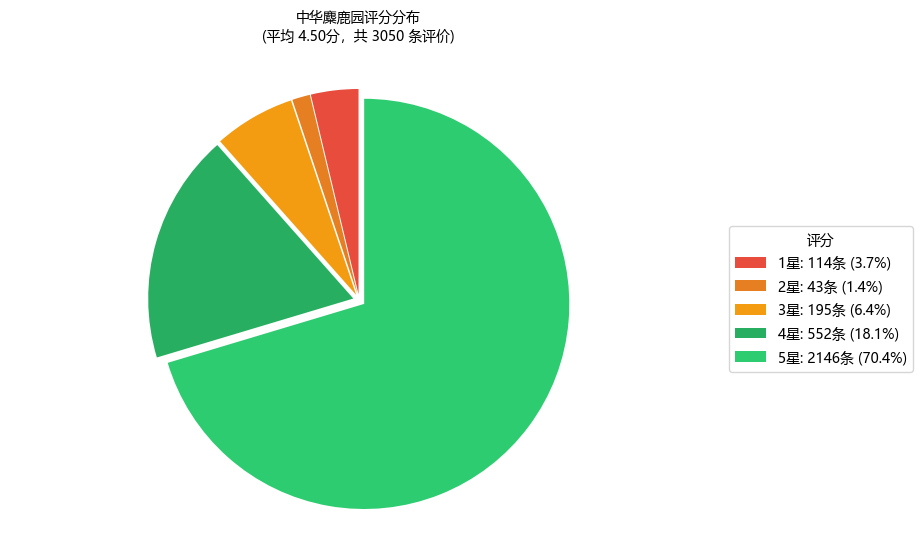

In [31]:
score_dist = df["总评分"].value_counts().sort_index()
labels = [f"{int(s)}星: {v}条 ({v/len(df)*100:.1f}%)" for s, v in score_dist.items()]
colors = [config.SCORE_COLORS[int(s)] for s in score_dist.index]

fig, ax = plt.subplots(figsize=(9, 6))
wedges, _ = ax.pie(
    score_dist.values,
    colors=colors,
    startangle=90,
    explode=[0.03] * len(score_dist),
    textprops={"fontsize": 11},
)
ax.legend(wedges, labels, title="评分", loc="center left",
          bbox_to_anchor=(1.02, 0.5), fontsize=11, title_fontproperties=font)
for t in ax.get_legend().get_texts():
    t.set_fontproperties(font)
ax.set_title(f"中华麋鹿园评分分布\n(平均 {df['总评分'].mean():.2f}分，共 {len(df)} 条评价)",
             fontsize=14, fontproperties=font, pad=20)
ax.axis("equal")
plt.show()

## 3. 评分维度对比（景色 / 趣味 / 性价比）

携程评价包含三个细分维度。对比三者的平均分，可定位景区的强项与短板。

C:\Users\39819\AppData\Local\Temp\ipykernel_35088\1594250642.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dim_scores.keys(), fontproperties=font, fontsize=12)


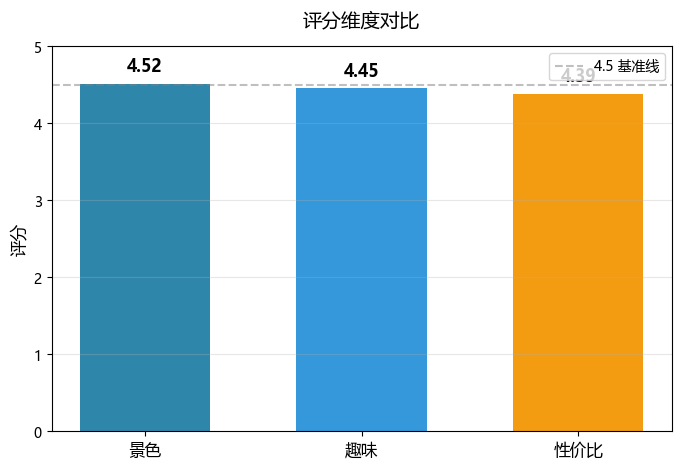

In [32]:
dim_scores = {
    "景色": df["景色评分"].mean(),
    "趣味": df["趣味评分"].mean(),
    "性价比": df["性价比评分"].mean(),
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dim_scores.keys(), dim_scores.values(),
             color=[config.COLORS["primary"], config.COLORS["info"], config.COLORS["warning"]],
             width=0.6)
ax.set_ylim(0, 5)
ax.set_ylabel("评分", fontproperties=font, fontsize=12)
ax.set_title("评分维度对比", fontproperties=font, fontsize=14, pad=15)
ax.set_xticklabels(dim_scores.keys(), fontproperties=font, fontsize=12)
for b, v in zip(bars, dim_scores.values()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1, f"{v:.2f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.axhline(4.5, color="gray", linestyle="--", alpha=0.5, label="4.5 基准线")
ax.legend(prop=font, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.show()

## 4. 时间趋势分析

从年度、月度、季节三个粒度观察评价量与评分的变化，识别增长拐点与淡旺季。

C:\Users\39819\AppData\Local\Temp\ipykernel_35088\635976376.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(yearly["年份"].astype(str), fontproperties=font, rotation=45)


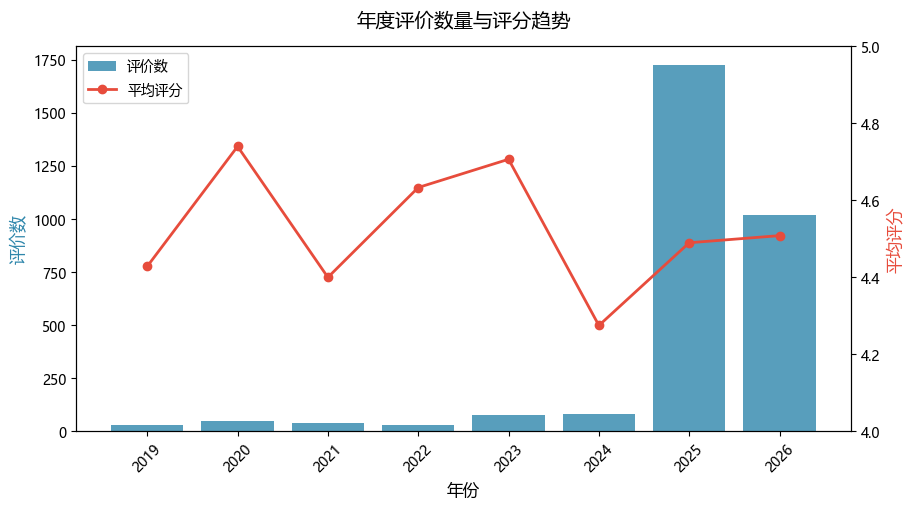

In [33]:
# 4.1 年度趋势（双 Y 轴：评价量柱状 + 平均评分折线）
yearly = df_valid.groupby("年份").agg(评价数=("评论ID", "count"), 平均评分=("总评分", "mean")).reset_index()
yearly = yearly[yearly["评价数"] >= config.MIN_YEAR_SAMPLES]  # 过滤样本过少的年份

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly["年份"].astype(str), yearly["评价数"], color=config.COLORS["primary"], alpha=0.8, label="评价数")
ax1.set_ylabel("评价数", color=config.COLORS["primary"], fontproperties=font, fontsize=12)
ax1.set_xlabel("年份", fontproperties=font, fontsize=12)
ax1.set_xticklabels(yearly["年份"].astype(str), fontproperties=font, rotation=45)
ax1.set_title("年度评价数量与评分趋势", fontproperties=font, fontsize=14, pad=15)

ax2 = ax1.twinx()
ax2.plot(yearly["年份"].astype(str), yearly["平均评分"], color=config.COLORS["danger"], marker="o", linewidth=2, label="平均评分")
ax2.set_ylabel("平均评分", color=config.COLORS["danger"], fontproperties=font, fontsize=12)
ax2.set_ylim(4, 5)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, prop=font, loc="upper left")
plt.show()

C:\Users\39819\AppData\Local\Temp\ipykernel_35088\741778046.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_recent["年月"], fontproperties=font, fontsize=9, rotation=45)


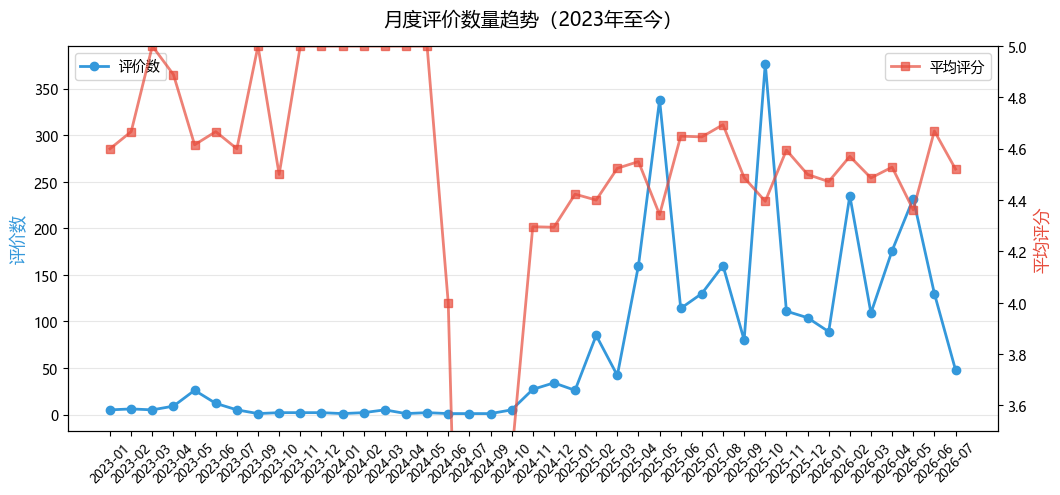

In [34]:
# 4.2 月度趋势（2023 年至今，双折线）
monthly = df_valid.groupby("年月").agg(评价数=("评论ID", "count"), 平均评分=("总评分", "mean")).reset_index()
monthly_recent = monthly[monthly["年月"] >= "2023-01"].sort_values("年月")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_recent["年月"], monthly_recent["评价数"], color=config.COLORS["info"], marker="o", linewidth=2, label="评价数")
ax1.set_ylabel("评价数", color=config.COLORS["info"], fontproperties=font, fontsize=12)
ax1.set_xticklabels(monthly_recent["年月"], fontproperties=font, fontsize=9, rotation=45)
ax1.set_title("月度评价数量趋势（2023年至今）", fontproperties=font, fontsize=14, pad=15)

ax2 = ax1.twinx()
ax2.plot(monthly_recent["年月"], monthly_recent["平均评分"], color=config.COLORS["danger"], marker="s", linewidth=2, alpha=0.7, label="平均评分")
ax2.set_ylabel("平均评分", color=config.COLORS["danger"], fontproperties=font, fontsize=12)
ax2.set_ylim(3.5, 5)

ax1.grid(axis="y", alpha=0.3)
ax1.legend(loc="upper left", prop=font)
ax2.legend(loc="upper right", prop=font)
plt.show()

C:\Users\39819\AppData\Local\Temp\ipykernel_35088\1351704901.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(seasonal["季节"], fontproperties=font, fontsize=11)


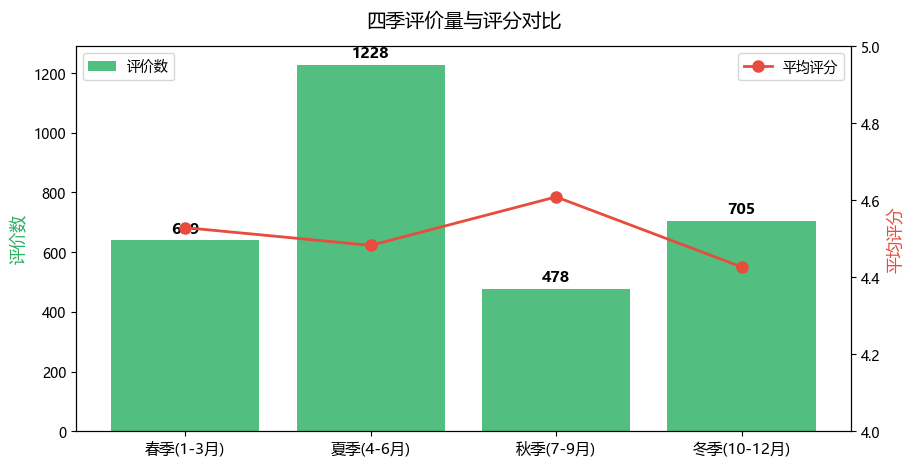

In [35]:
# 4.3 季节性分析（按春/夏/秋/冬排序）
seasonal = df_valid.groupby("季节").agg(评价数=("评论ID", "count"), 平均评分=("总评分", "mean")).reset_index()
seasonal = seasonal.set_index("季节").reindex(config.SEASON_ORDER).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(seasonal["季节"], seasonal["评价数"], color=config.COLORS["success"], alpha=0.8, label="评价数")
ax1.set_ylabel("评价数", color=config.COLORS["success"], fontproperties=font, fontsize=12)
ax1.set_xticklabels(seasonal["季节"], fontproperties=font, fontsize=11)
ax1.set_title("四季评价量与评分对比", fontproperties=font, fontsize=14, pad=15)
for b, v in zip(bars, seasonal["评价数"]):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 10, f"{int(v)}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(seasonal["季节"], seasonal["平均评分"], color=config.COLORS["danger"], marker="o", linewidth=2, markersize=8, label="平均评分")
ax2.set_ylabel("平均评分", color=config.COLORS["danger"], fontproperties=font, fontsize=12)
ax2.set_ylim(4, 5)
ax1.legend(loc="upper left", prop=font)
ax2.legend(loc="upper right", prop=font)
plt.show()

## 5. 用户画像

了解谁在评价：会员等级分布反映客群黏性，IP 属地 TOP10 反映客源地理结构。

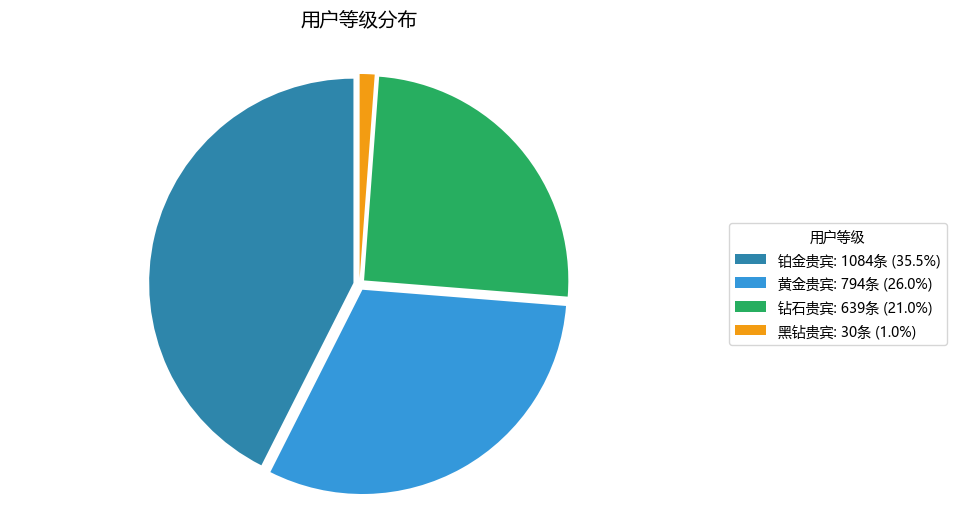

In [36]:
# 5.1 用户等级分布（右侧图例，避免小扇区遮挡）
member_dist = df["用户等级"].value_counts().head(6)
colors = [config.COLORS["primary"], config.COLORS["info"], config.COLORS["success"],
          config.COLORS["warning"], config.COLORS["danger"], config.COLORS["secondary"]]
labels = [f"{k}: {v}条 ({v/len(df)*100:.1f}%)" for k, v in member_dist.items()]

fig, ax = plt.subplots(figsize=(9, 6))
wedges, _ = ax.pie(member_dist.values, colors=colors, startangle=90,
                   explode=[0.03] * len(member_dist), textprops={"fontsize": 11})
ax.legend(wedges, labels, title="用户等级", loc="center left",
          bbox_to_anchor=(1.02, 0.5), fontsize=11, title_fontproperties=font)
for t in ax.get_legend().get_texts():
    t.set_fontproperties(font)
ax.set_title("用户等级分布", fontproperties=font, fontsize=14, pad=20)
ax.axis("equal")
plt.show()

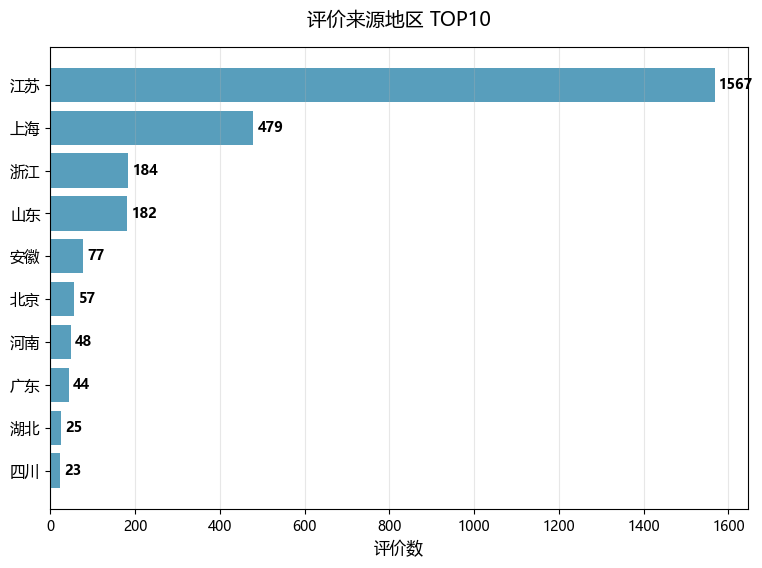

In [37]:
# 5.2 来源地区 TOP10（横向柱状图，数量最多的在最上方）
ip_dist = df["IP属地"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(ip_dist))
bars = ax.barh(y, ip_dist.values, color=config.COLORS["primary"], alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(ip_dist.index, fontproperties=font, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("评价数", fontproperties=font, fontsize=12)
ax.set_title("评价来源地区 TOP10", fontproperties=font, fontsize=14, pad=15)
for b, v in zip(bars, ip_dist.values):
    ax.text(v + 10, b.get_y() + b.get_height() / 2, f"{int(v)}", va="center", fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.show()

## 6. 评论文本分析

对评论做 jieba 分词 + 停用词过滤，观察评论长度分布、高频词与情感关键词。

C:\Users\39819\AppData\Local\Temp\ipykernel_35088\3487611.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(config.LENGTH_LABELS, fontproperties=font, fontsize=10, rotation=30)


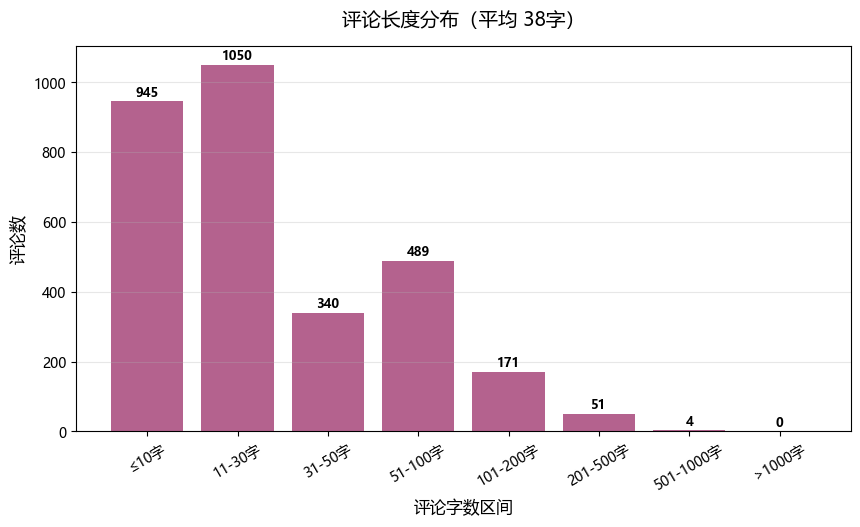

In [38]:
# 6.1 评论长度分布（按字数区间）
d = df_valid.copy()
d["长度区间"] = pd.cut(d["评论字数"], bins=config.LENGTH_BINS, labels=config.LENGTH_LABELS, right=True)
length_dist = d["长度区间"].value_counts().reindex(config.LENGTH_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(config.LENGTH_LABELS, length_dist.values, color=config.COLORS["secondary"], alpha=0.8)
ax.set_xlabel("评论字数区间", fontproperties=font, fontsize=12)
ax.set_ylabel("评论数", fontproperties=font, fontsize=12)
ax.set_title(f"评论长度分布（平均 {d['评论字数'].mean():.0f}字）", fontproperties=font, fontsize=14, pad=15)
ax.set_xticklabels(config.LENGTH_LABELS, fontproperties=font, fontsize=10, rotation=30)
for b, v in zip(bars, length_dist.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5, f"{int(v)}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.show()

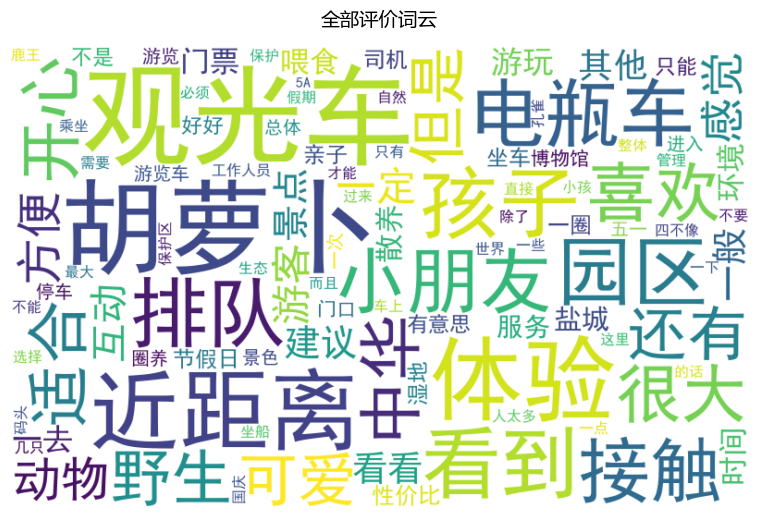

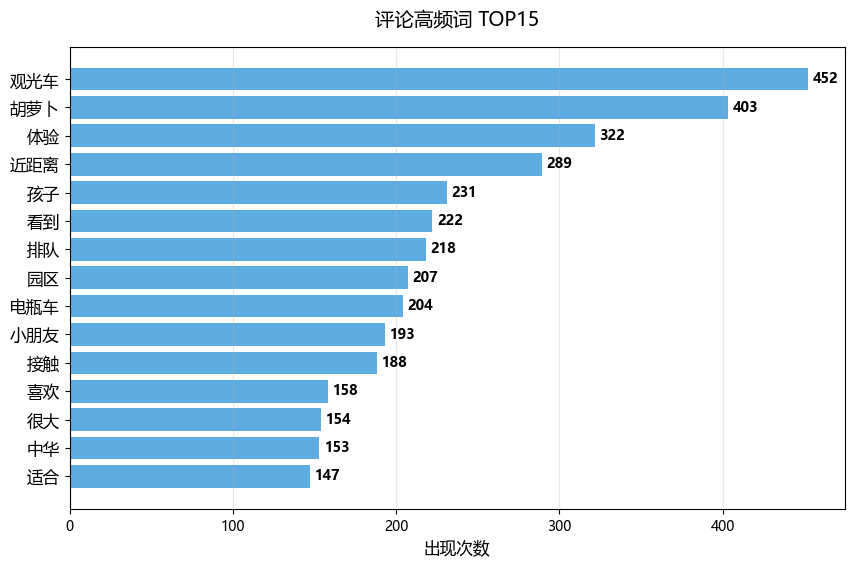

In [39]:
# 6.2 词云 + 高频词 TOP15
from wordcloud import WordCloud

word_freq = data_utils.word_frequency(df["评论内容"])
simhei = "C:/Windows/Fonts/simhei.ttf"
wc = WordCloud(
    font_path=simhei if os.path.exists(simhei) else None,
    width=800, height=500, background_color="white", max_words=100,
    colormap="viridis", max_font_size=120, min_font_size=10,
)
wc.generate_from_frequencies(dict(word_freq.most_common(100)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("全部评价词云", fontproperties=font, fontsize=14, pad=15)
plt.show()

words, counts = zip(*word_freq.most_common(15))
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(words))
bars = ax.barh(y, counts, color=config.COLORS["info"], alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(words, fontproperties=font, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("出现次数", fontproperties=font, fontsize=12)
ax.set_title("评论高频词 TOP15", fontproperties=font, fontsize=14, pad=15)
for b, v in zip(bars, counts):
    ax.text(v + 3, b.get_y() + b.get_height() / 2, f"{int(v)}", va="center", fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.show()

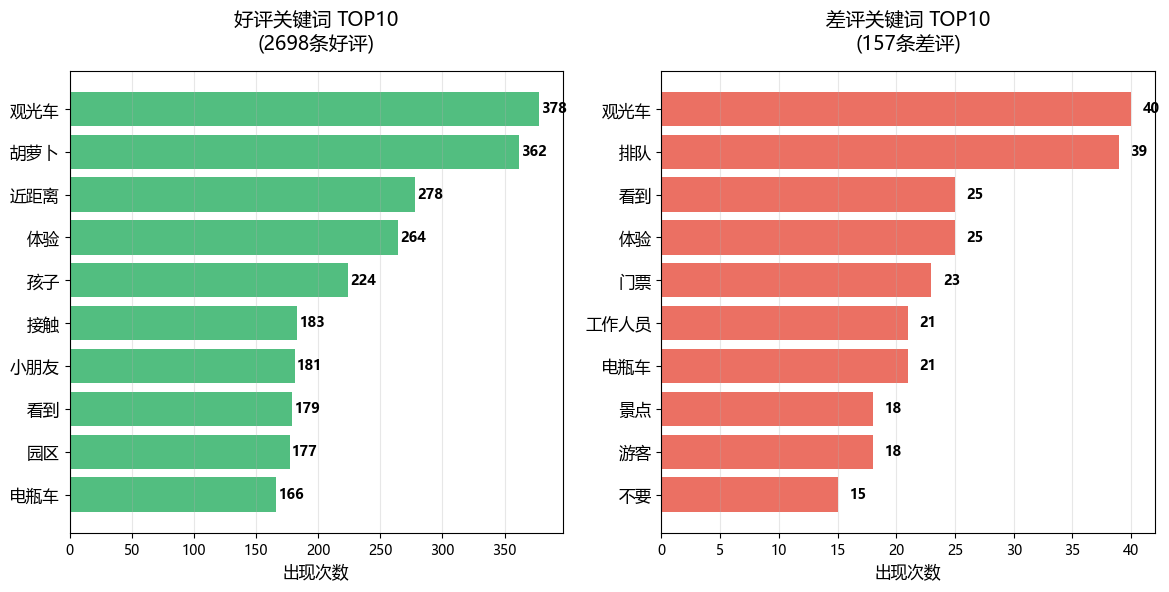

In [40]:
# 6.3 好评 vs 差评 关键词对比
df_pos = df_valid[df_valid["总评分"] >= config.POSITIVE_MIN_SCORE]
df_neg = df_valid[df_valid["总评分"] <= config.NEGATIVE_MAX_SCORE]
pos_freq = data_utils.word_frequency(df_pos["评论内容"], drop_digits=False).most_common(10)
neg_freq = data_utils.word_frequency(df_neg["评论内容"], drop_digits=False).most_common(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

pw, pc = zip(*pos_freq)
y = np.arange(len(pw))
b1 = ax1.barh(y, pc, color=config.COLORS["success"], alpha=0.8)
ax1.set_yticks(y); ax1.set_yticklabels(pw, fontproperties=font, fontsize=12); ax1.invert_yaxis()
ax1.set_xlabel("出现次数", fontproperties=font, fontsize=12)
ax1.set_title(f"好评关键词 TOP10\n({len(df_pos)}条好评)", fontproperties=font, fontsize=14, pad=15)
for b, v in zip(b1, pc):
    ax1.text(v + 2, b.get_y() + b.get_height() / 2, f"{int(v)}", va="center", fontsize=10, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

nw, nc = zip(*neg_freq)
y = np.arange(len(nw))
b2 = ax2.barh(y, nc, color=config.COLORS["danger"], alpha=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(nw, fontproperties=font, fontsize=12); ax2.invert_yaxis()
ax2.set_xlabel("出现次数", fontproperties=font, fontsize=12)
ax2.set_title(f"差评关键词 TOP10\n({len(df_neg)}条差评)", fontproperties=font, fontsize=14, pad=15)
for b, v in zip(b2, nc):
    ax2.text(v + 1, b.get_y() + b.get_height() / 2, f"{int(v)}", va="center", fontsize=10, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)
plt.show()

## 7. 交互式图表（pyecharts）

静态图适合报告，交互图适合探索。下面用 pyecharts 把评分分布做成可悬停查看明细的饼图，
调用 `render_notebook()` 即可在 Notebook 中直接渲染。完整 15 图交互仪表盘见 `src/analyze_reviews.py` 生成的 HTML。

In [41]:
from pyecharts import options as opts
from pyecharts.charts import Pie

pie = (
    # bg_color="white" 必须显式指定：default 主题背景是透明的，
    # 在暗色 Jupyter 主题下会透出黑色，导致图表背景发黑。
    Pie(init_opts=opts.InitOpts(width="700px", height="500px", theme="default", bg_color="white"))
    .add(
        "评价数",
        [(f"{int(s)}星", int(v)) for s, v in score_dist.items()],
        radius=["40%", "70%"],
        emphasis_opts=opts.EmphasisOpts(is_scale=False),  # 关闭悬停扇区放大，保持与静态图一致的稳重风格
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(title=f"中华麋鹿园评分分布（共 {len(df)} 条）"),
        legend_opts=opts.LegendOpts(orient="vertical", pos_left="right"),
    )
    .set_series_opts(label_opts=opts.LabelOpts(formatter="{b}: {c}"))
)
pie.render_notebook()

## 8. 分析摘要与结论

汇总关键指标，写出供 HTML 报告复用的摘要 JSON，并给出总体结论。

In [42]:
import json

summary = {
    "景区": config.SIGHT_FULL_NAME,
    "总评价数": int(len(df)),
    "平均总评分": round(float(df["总评分"].mean()), 2),
    "平均评论字数": round(float(df_valid["评论字数"].mean()), 1),
    "维度均分": {k: round(float(v), 2) for k, v in dim_scores.items()},
    "好评率(%)": round(float((df["总评分"] >= 4).mean()) * 100, 1),
    "差评率(%)": round(float((df["总评分"] <= 2).mean()) * 100, 1),
    "来源地区TOP3": ip_dist.head(3).index.tolist(),
    "高频词TOP10": list(words[:10]),
}
# 写出供 HTML 报告复用的摘要 JSON
config.SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("摘要已写入:", config.SUMMARY_JSON)
summary

摘要已写入: D:\Users\39819\Desktop\ctrip-milu-park-analysis-main\output\中华麋鹿园_分析摘要.json


{'景区': '盐城中华麋鹿园',
 '总评价数': 3050,
 '平均总评分': 4.5,
 '平均评论字数': 37.5,
 '维度均分': {'景色': 4.52, '趣味': 4.45, '性价比': 4.39},
 '好评率(%)': 88.5,
 '差评率(%)': 5.1,
 '来源地区TOP3': ['江苏', '上海', '浙江'],
 '高频词TOP10': ['观光车', '胡萝卜', '体验', '近距离', '孩子', '看到', '排队', '园区', '电瓶车', '小朋友']}

### 结论要点

- **整体口碑**：平均评分较高，好评率占主导；差评集中在少数体验痛点（见 6.3 差评关键词）。
- **时间趋势**：评价量逐年 / 逐月增长，说明景区热度与关注度在上升。
- **用户画像**：客源以周边省份为主，会员等级分布反映一定的复访与黏性。
- **文本洞察**：高频词体现核心游览价值；好评关键词印证优势，差评关键词指向待改进的运营短板。

> 本 Notebook 与 `src/` 下脚本共享 `config` 与 `data_utils`，修改配置后两端同步生效。